# DS Automation Assignment

# Task 1
Using our prepared churn data from week 2:
- use pycaret to find an ML algorithm that performs best on the data
    - Choose a metric you think is best to use for finding the best model; by default, it is accuracy but it could be AUC, precision, recall, etc. The week 3 FTE has some information on these different metrics.
- save the model to disk
- create a Python script/file/module with a function that takes a pandas dataframe as an input and returns the probability of churn for each row in the dataframe
    - your Python file/function should print out the predictions for new data (new_churn_data.csv)
    - the true values for the new data are [1, 0, 0, 1, 0] if you're interested
- test your Python module and function with the new data, new_churn_data.csv
- write a short summary of the process and results at the end of this notebook
- upload this Jupyter Notebook and Python file to a Github repository, and turn in a link to the repository in the week 5 assignment dropbox

Additional challenges:
- return the probability of churn for each new prediction, and the percentile where that prediction is in the distribution of probability predictions from the training dataset (e.g. a high probability of churn like 0.78 might be at the 90th percentile)
- use other autoML packages, such as TPOT, H2O, MLBox, etc, and compare performance and features with pycaret
- create a class in your Python module to hold the functions that you created
- accept user input to specify a file using a tool such as Python's `input()` function, the `click` package for command-line arguments, or a GUI
- Use the unmodified churn data (new_unmodified_churn_data.csv) in your Python script. This will require adding the same preprocessing steps from week 2 since this data is like the original unmodified dataset from week 1.


# Task 2: Critical Reflection
What are your observations based on the analyses you had performed? Is there one model that seems particularly useful for predicting churn. Why or why not?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from pycaret.classification import setup, compare_models, predict_model, save_model, load_model, pull

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams.update({"figure.figsize": (10, 6), "axes.titleweight": "bold", "savefig.dpi": 150})
%matplotlib inline

df = pd.read_csv("churn_data_prepped.csv")

# quick sanity check before we start automating
print(f"{df.shape[0]:,} records, {df.shape[1]} features")
print(f"Churn split: {df['Churn'].value_counts().to_dict()}")
df.head()

7,043 records, 10 features
Churn split: {0: 5174, 1: 1869}


,tenure,PhoneService,Contract,MonthlyCharges,TotalCharges,Churn,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,avg_monthly
0,1,0,0,29.85,29.85,0,False,True,False,29.850000
1,34,1,1,56.95,1889.50,0,False,False,True,55.573529
2,2,1,0,53.85,108.15,1,False,False,True,54.075000
3,45,0,1,42.30,1840.75,0,False,False,False,40.905556
4,2,1,0,70.70,151.65,1,False,True,False,75.825000


In [2]:
exp = setup(df, target="Churn", train_size=0.75, session_id=42, fold=5, normalize=True, verbose=False)

print(f"Train: {exp.X_train.shape[0]:,} rows, Test: {exp.X_test.shape[0]:,} rows")
print(f"Train churn rate: {exp.y_train.mean():.1%}, Test churn rate: {exp.y_test.mean():.1%}")

Train: 5,282 rows, Test: 1,761 rows
Train churn rate: 26.5%, Test churn rate: 26.5%


I sorted compare_models by AUC instead of the default accuracy. Week 3 showed why accuracy is misleading on this data. The logistic regression hit 79.2%, only 5.7 points above the 73.5% no-information rate, while catching barely half the churners. Recall alone has the opposite problem, since flagging every customer scores 100%. AUC measures how well a model ranks churners above non-churners across every threshold, which is what matters for a script that returns probabilities and percentiles instead of a single yes or no.

In [3]:
best = compare_models(sort="AUC")

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lr,Logistic Regression,0.7931,0.8337,0.5043,0.6424,0.5640,0.4310,0.4371,0.2260
gbc,Gradient Boosting Classifier,0.7897,0.8337,0.4764,0.6414,0.5457,0.4128,0.4212,0.0640
ada,Ada Boost Classifier,0.7900,0.8321,0.5021,0.6328,0.5594,0.4240,0.4292,0.0220
lightgbm,Light Gradient Boosting Machine,0.7817,0.8246,0.5007,0.6091,0.5487,0.4067,0.4107,0.8360
ridge,Ridge Classifier,0.7891,0.8213,0.4322,0.6603,0.5212,0.3934,0.4087,0.1520
lda,Linear Discriminant Analysis,0.7904,0.8213,0.5000,0.6356,0.5587,0.4239,0.4298,0.0060
qda,Quadratic Discriminant Analysis,0.7503,0.8186,0.7033,0.5227,0.5994,0.4238,0.4338,0.1540
nb,Naive Bayes,0.7450,0.8101,0.6961,0.5149,0.5918,0.4124,0.4225,0.1660
svm,SVM - Linear Kernel,0.7690,0.8067,0.5450,0.5831,0.5534,0.4002,0.4067,0.1600
rf,Random Forest Classifier,0.7770,0.7984,0.4837,0.6007,0.5343,0.3903,0.3951,0.1720


In [4]:
test_preds = predict_model(best)

tn, fp, fn, tp = pd.crosstab(test_preds["Churn"], test_preds["prediction_label"]).values.ravel()
print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")
print(f"Recall: {tp / (tp + fn):.1%}, Precision: {tp / (tp + fp):.1%}")

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Logistic Regression,0.7922,0.8404,0.5182,0.6319,0.5694,0.4342,0.4379


TN=1153, FP=141, FN=225, TP=242
Recall: 51.8%, Precision: 63.2%


In [5]:
save_model(best, "churn_lr_model")

train_probs = predict_model(best, data=exp.X_train, raw_score=True)["prediction_score_1"]
train_probs.to_csv("train_churn_probs.csv", index=False)
print(f"Saved model and {len(train_probs):,} training probabilities")

Transformation Pipeline and Model Successfully Saved


Saved model and 5,282 training probabilities


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from pycaret.classification import setup, compare_models, predict_model, save_model, load_model, pull
from predict_churn import ChurnPredictor

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams.update({"figure.figsize": (10, 6), "axes.titleweight": "bold", "savefig.dpi": 150})
%matplotlib inline

df = pd.read_csv("churn_data_prepped.csv")

# quick sanity check before we start automating
print(f"{df.shape[0]:,} records, {df.shape[1]} features")
print(f"Churn split: {df['Churn'].value_counts().to_dict()}")
df.head()

7,043 records, 10 features
Churn split: {0: 5174, 1: 1869}


,tenure,PhoneService,Contract,MonthlyCharges,TotalCharges,Churn,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,avg_monthly
0,1,0,0,29.85,29.85,0,False,True,False,29.850000
1,34,1,1,56.95,1889.50,0,False,False,True,55.573529
2,2,1,0,53.85,108.15,1,False,False,True,54.075000
3,45,0,1,42.30,1840.75,0,False,False,False,40.905556
4,2,1,0,70.70,151.65,1,False,True,False,75.825000


In [7]:
predictor = ChurnPredictor()
unmodified = predictor.predict(predictor.load_data("new_churn_data_unmodified.csv"))
encoded = predictor.predict(predictor.load_data("new_churn_data.csv"))

comparison = pd.DataFrame({
    "Actual": [1, 0, 0, 1, 0],
    "Unmodified prob": unmodified["churn_probability"],
    "Unmodified pred": unmodified["prediction"].eq("Churn").astype(int),
    "Encoded prob": encoded["churn_probability"],
    "Encoded pred": encoded["prediction"].eq("Churn").astype(int),
}, index=unmodified.index)

print(f"Unmodified correct: {(comparison['Unmodified pred'] == comparison['Actual']).sum()}/5")
print(f"Encoded correct: {(comparison['Encoded pred'] == comparison['Actual']).sum()}/5")
comparison

Unmodified correct: 3/5
Encoded correct: 2/5


,Actual,Unmodified prob,Unmodified pred,Encoded prob,Encoded pred
customerID,,,,,
9305-CKSKC,1,0.549,1,0.549,1
1452-KNGVK,0,0.571,1,0.571,1
6723-OKKJM,0,0.076,0,0.076,0
7832-POPKP,1,0.222,0,0.222,0
6348-TACGU,0,0.305,0,0.756,1


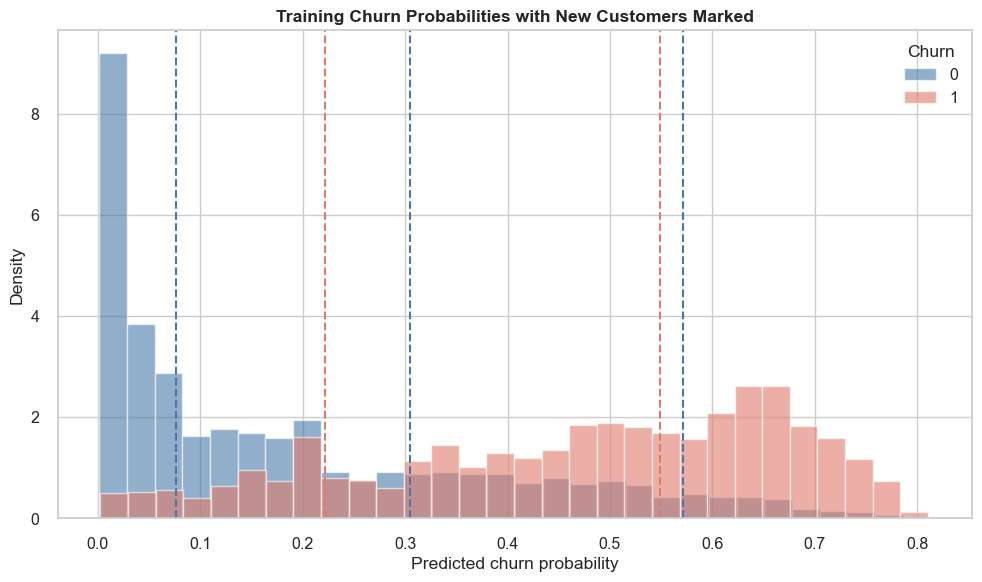

In [8]:
train_scored = pd.DataFrame({"prob": train_probs.values, "Churn": exp.y_train.values})

fig, ax = plt.subplots()
for label, color in [(0, "#4878A8"), (1, "#E07B6C")]:
    subset = train_scored[train_scored["Churn"] == label]["prob"]
    ax.hist(subset, bins=30, alpha=0.6, color=color, label=str(label), density=True)
for _, row in comparison.iterrows():
    ax.axvline(row["Unmodified prob"], color="#E07B6C" if row["Actual"] == 1 else "#4878A8", linestyle="--", linewidth=1.5)
ax.set_title("Training Churn Probabilities with New Customers Marked")
ax.set_xlabel("Predicted churn probability")
ax.set_ylabel("Density")
ax.legend(title="Churn", frameon=False)
plt.tight_layout()
plt.show()

| # | My prediction (before analysis) | What I actually found | Was I right? |
|---|---|---|---|
| 1 | The new data would break the script, since its columns don't match churn_data_prepped.csv | Two expected mismatches (charge_per_tenure instead of avg_monthly, PaymentMethod as a single integer) plus one I didn't expect: 6348-TACGU is coded month-to-month despite a two-year contract, which moved its churn probability from 0.305 to 0.756 | Yes, and it was worse than I thought. The mismatches I saw coming were easy to fix. The one I didn't see changed a prediction. |
| 2 | Testing 14 algorithms would beat my best hand-built model from Week 4 (79.6% test) | Logistic regression won at 79.3% CV and 79.2% test, with a confusion matrix identical to Week 3 (TN=1153, FP=141, FN=225, TP=242) | No. Automation confirmed my Week 3 model instead of improving on it. |
| 3 | No strong expectation about which model type would win | Logistic regression and gradient boosting tied at 0.8337 AUC. The untuned decision tree (0.652) and random forest (0.798) finished near the bottom | No prediction to miss, but the tree results should have been obvious from the Week 4 overfitting. |

Logistic regression is the most useful model here, though not because it was clearly better. It tied gradient boosting at 0.8337 AUC, reproduced my Week 3 confusion matrix exactly, and is the easiest of the top models to explain to a retention team. The bigger lesson came from the new data. The instructor's pre-encoded file lists 6348-TACGU as month-to-month when the source shows a two-year contract, and that one value moved the churn probability from 0.305 to 0.756 and dropped the model from 3 of 5 correct to 2 of 5. A model is only as useful as the data it's handed, and I wouldn't score a pre-encoded file again without first checking it against the raw source, especially when the error lands on Contract, the feature that carried 0.395 of the importance in Week 4.

# Summary

I started with the Week 2 prepped data and set PyCaret up to match my Week 3 split exactly, 75/25 stratified with the same seed, which gave 5,282 training rows and 1,761 test rows at 26.5% churn in both. From there I let compare_models run 14 algorithms with 5-fold cross-validation and sorted by AUC instead of accuracy, since Week 3 already showed how little 79% accuracy means against a 73.5% baseline.

Logistic regression came out on top at 0.8337 AUC, tied with gradient boosting, and on the test set it scored 79.2% accuracy and 0.840 AUC. The confusion matrix came out identical to Week 3, TN=1153, FP=141, FN=225, TP=242. So after trying everything PyCaret had, I ended up with the same model I built by hand. The untuned decision tree (0.652 AUC) and random forest (0.798) landed near the bottom for the same reason as in Week 4, since PyCaret runs them at unlimited depth and they overfit. My tuned forest from Week 4 still holds the best test accuracy at 79.6%.

I saved the model and built predict_churn.py around a ChurnPredictor class. It applies my Week 2 preprocessing to the unmodified data, takes a file from the command line with click, and returns each customer's churn probability along with its percentile among the 5,282 training predictions. On the five new customers it got 3 right. It caught 9305-CKSKC at 0.549 (83.9th percentile) and correctly cleared two others, but missed 7832-POPKP at 0.222 and flagged 1452-KNGVK at 0.571. That last one has 1,701.95 in total charges over 8 months, which works out to 212.74 a month against a monthly charge of 77.30, so the inflated spending features are likely what pushed it over.

Running the instructor's pre-encoded file instead dropped the result to 2 of 5. That file codes 6348-TACGU as month-to-month when the raw data shows a two-year contract, and that single value moved the prediction from 0.305 to 0.756, the 99.2nd percentile. With Contract carrying 0.395 of the importance in Week 4, one bad value there outweighs everything else about the customer.

The probability histogram shows where the model's limits are. Non-churners stack up near zero, but churners spread from about 0.2 to 0.8, and the model never goes much above 0.82. Every churner between 0.2 and 0.5 falls under the default threshold, which is why recall has sat around 51.8% since Week 3 no matter which algorithm I use. The next gains won't come from another model. They'll come from a lower threshold tuned to what a missed churner actually costs, or from better features, and this script is already most of the way to the nightly batch scoring I described for deployment in Week 3.

In [ ]:
!jupyter nbconvert --to html "Week_5_assignment_starter.ipynb"